In [1]:
# Bibliotecas 

import cv2
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from skimage.measure import regionprops
from skimage.measure import label as sk_label

### 1. Cargar una imagen.

In [2]:
img = cv2.imread('dune.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

### 2. Convierte la imagen a escala de grises si es necesario. Aplica un filtro de suavizado para reducir el ruido.

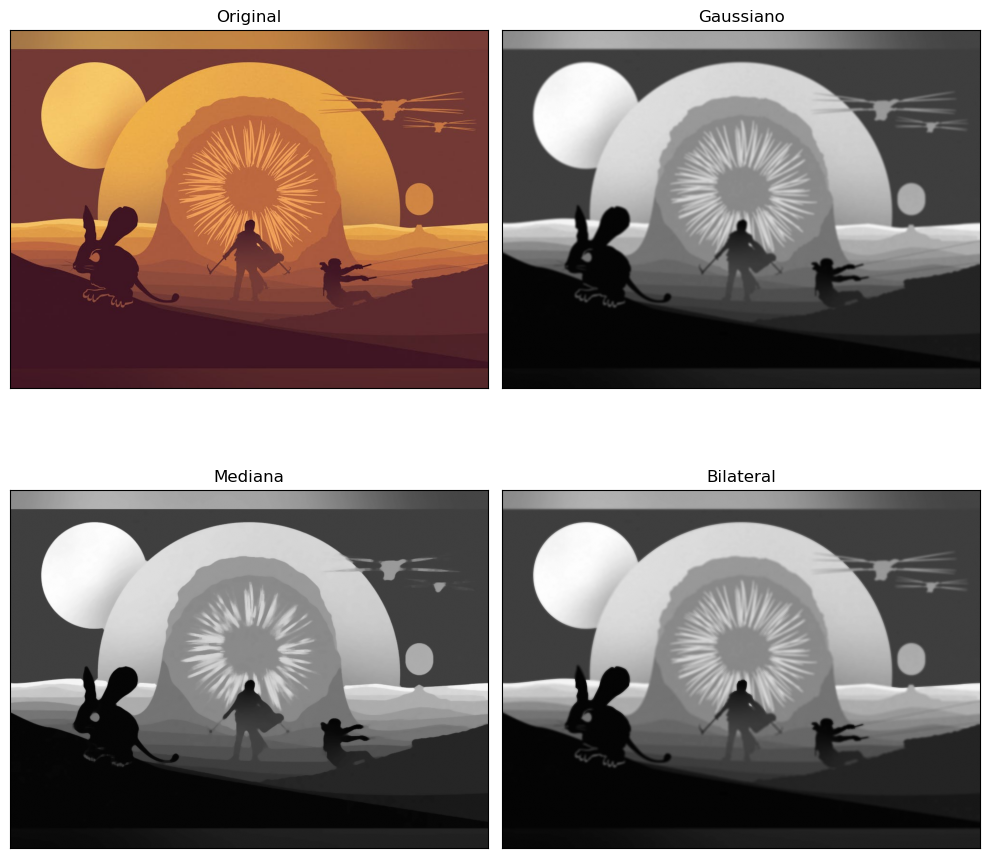

In [3]:
img_ = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

gaussian = cv2.GaussianBlur(img_, (9, 9), 2)
median = cv2.medianBlur(img_, 9)
bilateral = cv2.bilateralFilter(img_, 9, 75, 70)

imagenes = [img, gaussian, median, bilateral]

titulos = ['Original', 'Gaussiano', 'Mediana', 'Bilateral']

plt.figure(figsize = (10, 10))

for i in range(len(imagenes)):

    plt.subplot(2, 2, i + 1) 
    plt.imshow(imagenes[i], cmap = 'gray')
    plt.title(titulos[i])
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

### 3. Utiliza el operador de Prewitt o Sobel para detectar bordes en la imagen.

In [4]:
sobelx = cv2.Sobel(gaussian, cv2.CV_64F, 1, 0, ksize = 3)
sobely = cv2.Sobel(gaussian, cv2.CV_64F, 0, 1, ksize = 3)
sobel_magnitud = np.sqrt(sobelx**2 + sobely**2)
sobel_magnitud = np.uint8(255 * sobel_magnitud / np.max(sobel_magnitud))

kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewittx = cv2.filter2D(gaussian, cv2.CV_64F, kernelx)
prewitty = cv2.filter2D(gaussian, cv2.CV_64F, kernely)
prewitt_magnitude = np.sqrt(prewittx**2 + prewitty**2)
prewitt_magnitude = np.uint8(255 * prewitt_magnitude / np.max(prewitt_magnitude))

### 4. Utiliza la transformada de Hough para detectar líneas o círculos en la imagen. Extrae propiedades de regiones.

In [5]:
# Binarizamos la imagen de bordes
_, umbralizada = cv2.threshold(sobel_magnitud, 50, 255, cv2.THRESH_BINARY)

# Etiquetamos las regiones conectadas
imagen_etiquetada = sk_label(umbralizada)

propiedades = regionprops(imagen_etiquetada)

print(f"Total de regiones: {len(propiedades)}.\n")

propiedades_ordenadas = sorted(propiedades, key = lambda p: p.area, reverse = True)

for i, prop in enumerate(propiedades_ordenadas[:5]):

    print(f"Región {i+1}:")
    print(f"  - Área: {prop.area} píxeles")
    print(f"  - Perímetro: {prop.perimeter:.2f}")
    print(f"  - Excentricidad: {prop.eccentricity:.2f}")
    print(f"  - Centro de masa (y, x): ({prop.centroid[0]:.2f}, {prop.centroid[1]:.2f})")

Total de regiones: 202.

Región 1:
  - Área: 12048.0 píxeles
  - Perímetro: 4586.89
  - Excentricidad: 0.79
  - Centro de masa (y, x): (244.00, 332.55)
Región 2:
  - Área: 4386.0 píxeles
  - Perímetro: 1789.76
  - Excentricidad: 0.76
  - Centro de masa (y, x): (322.29, 819.72)
Región 3:
  - Área: 3835.0 píxeles
  - Perímetro: 1499.18
  - Excentricidad: 1.00
  - Centro de masa (y, x): (41.52, 353.91)
Región 4:
  - Área: 2849.0 píxeles
  - Perímetro: 1085.42
  - Excentricidad: 0.56
  - Centro de masa (y, x): (447.42, 101.54)
Región 5:
  - Área: 2247.0 píxeles
  - Perímetro: 1021.08
  - Excentricidad: 0.73
  - Centro de masa (y, x): (445.40, 492.96)


In [6]:
def detectar_circulo(imagen, titulo):

    if len(imagen.shape) == 3: 

        img_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)
        img_dibujo = imagen.copy()

    else: 

        img_gris = imagen
        img_dibujo = cv2.cvtColor(imagen, cv2.COLOR_GRAY2RGB) 

    circulos = cv2.HoughCircles(
        img_gris, 
        cv2.HOUGH_GRADIENT,
        dp = 1, 
        minDist = 25, 
        param1 = 150, 
        param2 = 30, 
        minRadius = 0, 
        maxRadius = 0
    )

    if circulos is not None:

        circulos = np.uint16(np.around(circulos))

        for c in circulos[0, :]:
            
            cv2.circle(img_dibujo, (c[0], c[1]), c[2], (0, 255, 0), 2)
            cv2.circle(img_dibujo, (c[0], c[1]), 2, (255, 0, 0), 3)
            
    plt.imshow(img_dibujo)
    plt.title(titulo)
    plt.xticks([]), plt.yticks([])

In [ ]:
# Diferencia entre Sobel y Prewitt
diferencia = cv2.absdiff(sobel_magnitud, prewitt_magnitude)

diferencia_resaltada = cv2.normalize(diferencia, None, 0, 255, cv2.NORM_MINMAX)

### 5. Visualizar y comparar los resultados: 
- Visualiza los resultados de cada paso (imagen suavizada, bordes detectados, círculos detectados, etc.).
- Analiza las características extraídas (formas, bordes) y su relación con el contenido de la imagen.

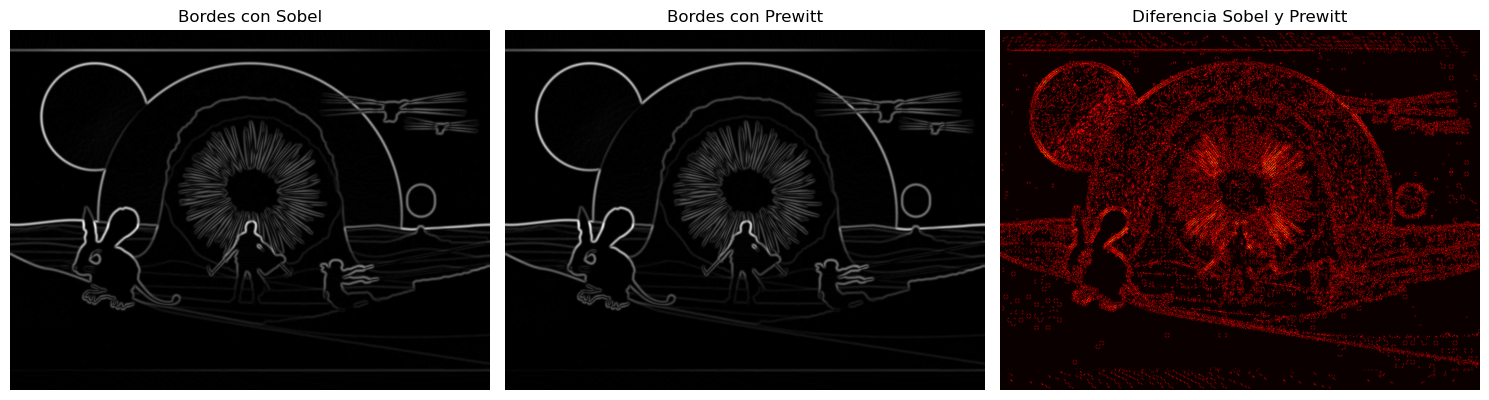

In [8]:
plt.figure(figsize = (15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sobel_magnitud, cmap = 'gray')
plt.title('Bordes con Sobel')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(prewitt_magnitude, cmap = 'gray')
plt.title('Bordes con Prewitt')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(diferencia_resaltada, cmap = 'hot') # Los cambios brillan
plt.title('Diferencia Sobel y Prewitt')
plt.axis('off')

plt.tight_layout()
plt.show()

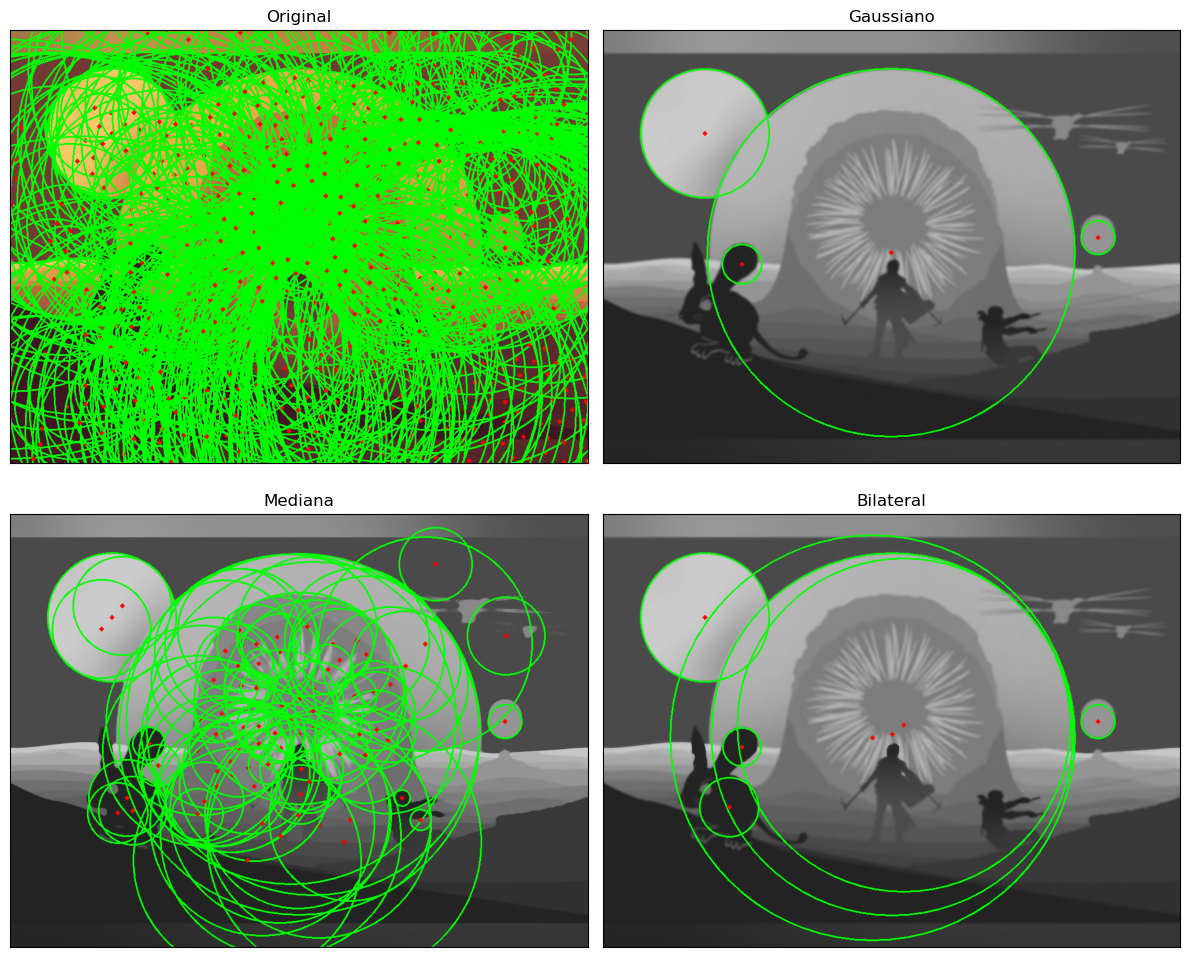

In [9]:
plt.figure(figsize = (12, 10))

for i in range(len(imagenes)):

    plt.subplot(2, 2, i + 1) 
    detectar_circulo(imagenes[i], titulos[i])

plt.tight_layout()
plt.show()

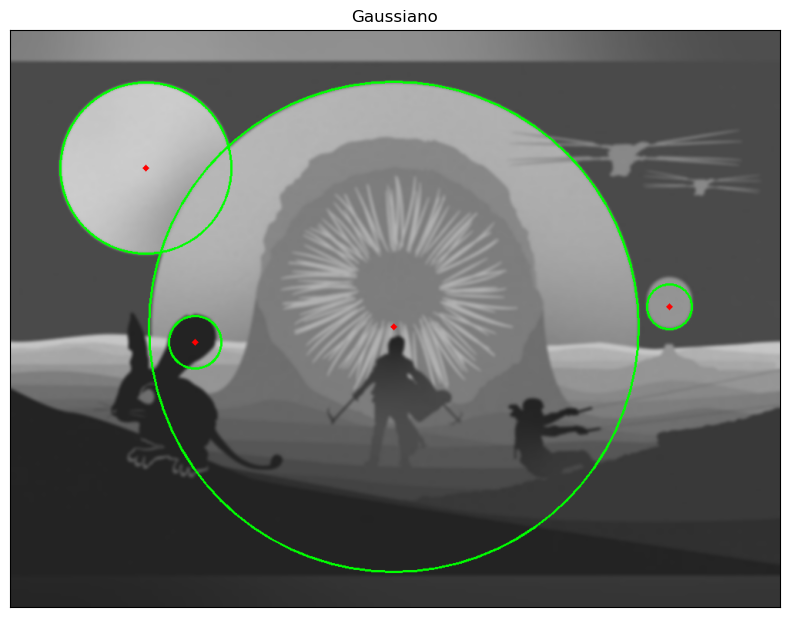

In [10]:
plt.figure(figsize = (8,8))
detectar_circulo(imagenes[1], titulos[1])

plt.tight_layout()
plt.show()